# **Customer Churn Prediction**

### **Import libraries and load dataset**

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [222]:
data=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [223]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [224]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### **Data Cleaning**

In [225]:
data['TotalCharges']=pd.to_numeric(data['TotalCharges'], errors="coerce")
data.drop_duplicates(inplace=True)
data.fillna(data.median(numeric_only=True), inplace=True)

### **Exploratory Data Analysis**

[]

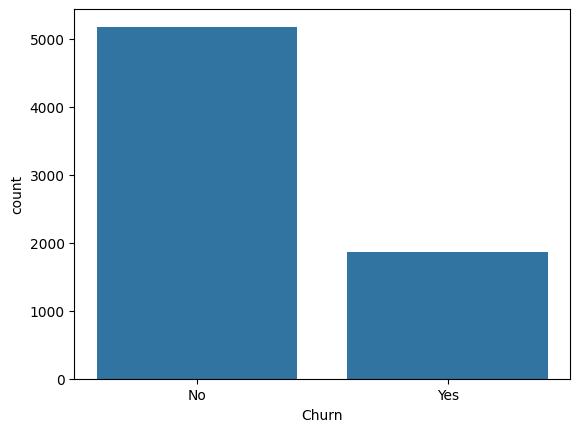

In [226]:
sns.countplot(x="Churn",data=data)
plt.plot()

<Axes: >

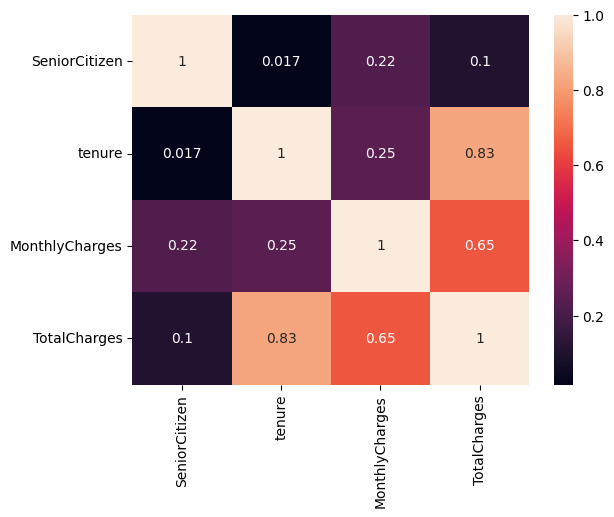

In [227]:
corr=data.corr(numeric_only=True)
sns.heatmap(corr, cbar=True, annot=True)

### **Feature Engineering**

In [228]:
data=data.drop('tenure',axis=1)
data=pd.get_dummies(data,drop_first=True)
data

,SeniorCitizen,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,29.85,29.85,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,56.95,1889.50,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,53.85,108.15,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,42.30,1840.75,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,70.70,151.65,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,84.80,1990.50,False,False,False,False,False,False,False,...,True,False,True,True,False,True,False,False,True,False
7039,0,103.20,7362.90,False,False,False,False,False,False,False,...,True,False,True,True,False,True,True,False,False,False
7040,0,29.60,346.45,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
7041,1,74.40,306.60,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True


In [229]:
from sklearn.preprocessing import StandardScaler
lr=StandardScaler()
nums_cols=['MonthlyCharges','TotalCharges']
data[nums_cols]=lr.fit_transform(data[nums_cols])


In [230]:
# data["Average"]=data["TotalCharges"]/(data["tenure"]+1)

In [231]:
from sklearn.model_selection import train_test_split

x=data.drop("Churn_Yes", axis=1)
y=data['Churn_Yes']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2)
print(x_train.shape)
print(x_test.shape)

(5634, 7071)
(1409, 7071)


In [232]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
y_pred

array([False, False, False, ..., False, False, False])

Accuracy :  0.8119233498935415
Precision Score :  0.6836734693877551
Recall score :  0.5388739946380697
f1_score :  0.6026986506746627


<Axes: >

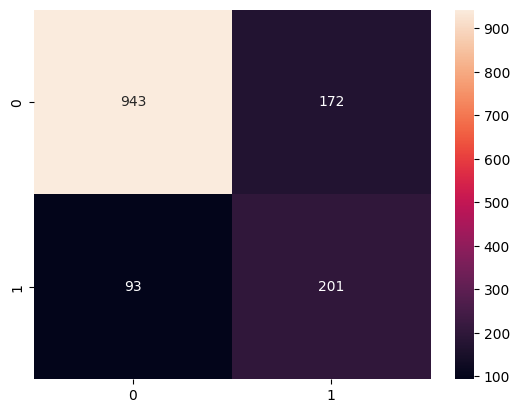

In [233]:
from sklearn.metrics import r2_score, recall_score, precision_score, accuracy_score, f1_score, confusion_matrix

print("Accuracy : ", accuracy_score(y_test,y_pred))
print("Precision Score : ", precision_score(y_test,y_pred))
print("Recall score : ", recall_score(y_test,y_pred))
print("f1_score : ", f1_score(y_test, y_pred))

sns.heatmap(confusion_matrix(y_pred, y_test), annot=True, fmt="d")

In [234]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test,y_pred))

0.724552827434865


### **Decision Tree**

In [235]:
from sklearn.tree import DecisionTreeClassifier
lr=DecisionTreeClassifier()
lr.fit(x_train,y_train)

y_pred=lr.predict(x_test)
y_pred

array([False, False, False, ..., False,  True, False])

Accuracy :  0.765791341376863
Precision Score :  0.5682539682539682
Recall score :  0.47989276139410186
f1_score :  0.5203488372093024


<Axes: >

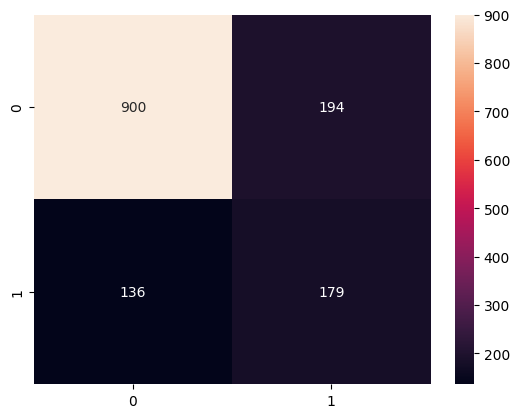

In [236]:
from sklearn.metrics import r2_score, recall_score, precision_score, accuracy_score, f1_score, confusion_matrix

print("Accuracy : ", accuracy_score(y_test,y_pred))
print("Precision Score : ", precision_score(y_test,y_pred))
print("Recall score : ", recall_score(y_test,y_pred))
print("f1_score : ", f1_score(y_test, y_pred))

sns.heatmap(confusion_matrix(y_pred, y_test), annot=True, fmt="d")

### **Random Forest**

In [237]:
from sklearn.ensemble import RandomForestClassifier
lr=RandomForestClassifier()
lr.fit(x_train,y_train)

y_pred=lr.predict(x_test)
y_pred

array([False, False, False, ..., False, False, False])

Accuracy :  0.8069552874378992
Precision Score :  0.7095435684647303
Recall score :  0.4584450402144772
f1_score :  0.5570032573289903


<Axes: >

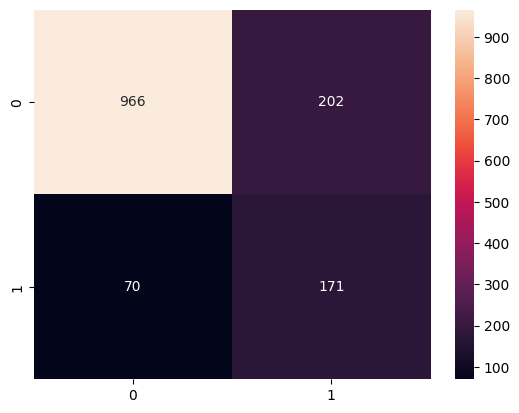

In [238]:
from sklearn.metrics import r2_score, recall_score, precision_score, accuracy_score, f1_score, confusion_matrix

print("Accuracy : ", accuracy_score(y_test,y_pred))
print("Precision Score : ", precision_score(y_test,y_pred))
print("Recall score : ", recall_score(y_test,y_pred))
print("f1_score : ", f1_score(y_test, y_pred))

sns.heatmap(confusion_matrix(y_pred, y_test), annot=True, fmt="d")